# Employee Turnover Prediction for Responsible HR AI

**Project positioning:** Explainable AI + Ethical AI

This notebook turns the initial exploration into a jury-ready workflow:
- pseudonymize employee names while keeping `EmpID` available for controlled HR follow-up;
- clean the target and remove leakage;
- engineer time features correctly from historical review dates;
- train an explainable baseline model;
- audit fairness on sensitive attributes without using them for training;
- compare models to justify the final deployment choice;
- explain both global and local predictions;
- reproduce the deployed dashboard logic for the Top 5, probable reasons, and HR actions.

## Use Case, Persona, and Responsible AI Scope

**Use case**  
Help HR identify the **top 5 active employees most at risk of voluntary turnover**, explain the main drivers behind that risk, estimate a probable resignation reason, and suggest concrete retention actions.

**Primary persona**  
HR Business Partner who needs an interpretable decision-support tool to prioritize retention actions.

**Themes selected**
1. **Explainable AI**: every prediction must be understandable and defensible.
2. **Ethical AI**: sensitive attributes are kept for audit only, not for model training.

**Model selection note**  
A Logistic Regression model is compared with a Random Forest only to justify the final deployment choice. This comparison is not presented as a separate hackathon theme.

In [ ]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [ ]:
CANDIDATE_DATA_PATHS = [
    Path("../data/HRDataset_v14.csv"),
    Path("data/HRDataset_v14.csv"),
    Path("Hackathon_AI_explainability-/data/HRDataset_v14.csv"),
]

DATA_PATH = next((candidate for candidate in CANDIDATE_DATA_PATHS if candidate.exists()), CANDIDATE_DATA_PATHS[0])
TARGET = "Termd"
TOP_N = 5

VOLUNTARY_REASONS = [
    "Another position",
    "unhappy",
    "more money",
    "career change",
    "hours",
    "return to school",
    "relocation out of area",
    "maternity leave - did not return",
    "retiring",
    "military",
    "medical issues",
]

REASON_GROUP_MAP = {
    "Another position": "Compensation/Career",
    "more money": "Compensation/Career",
    "career change": "Compensation/Career",
    "unhappy": "Work Conditions/Engagement",
    "hours": "Work Conditions/Engagement",
    "return to school": "Personal/External",
    "maternity leave - did not return": "Personal/External",
    "relocation out of area": "Personal/External",
    "military": "Personal/External",
    "medical issues": "Personal/External",
    "retiring": "Personal/External",
}

REASON_DISPLAY_MAP = {
    "Compensation/Career": "Compensation or career",
    "Work Conditions/Engagement": "Work conditions or engagement",
    "Personal/External": "Personal or external factors",
}

LEAKAGE_COLUMNS = [
    "TermReason",
    "DateofTermination",
    "EmploymentStatus",
    "EmpStatusID",
]

IDENTIFIER_COLUMNS = [
    "Employee_Name",
    "EmpID",
    "ManagerName",
]

SENSITIVE_AUDIT_COLUMNS = [
    "Sex",
    "RaceDesc",
    "GenderID",
    "CitizenDesc",
    "HispanicLatino",
]

MODEL_FEATURES = [
    "MaritalDesc",
    "Salary",
    "Position",
    "Department",
    "RecruitmentSource",
    "PerformanceScore",
    "EngagementSurvey",
    "EmpSatisfaction",
    "SpecialProjectsCount",
    "DaysLateLast30",
    "Absences",
    "FromDiversityJobFairID",
    "AgeAtReview",
    "TenureAtReview",
    "State",
]


def anonymize_employee_names(frame: pd.DataFrame) -> pd.DataFrame:
    anonymized = frame.copy()
    anonymized["Employee_Alias"] = [f"EMP_{i + 1:03d}" for i in range(len(anonymized))]
    return anonymized


def parse_dob_with_century_fix(series: pd.Series, reference_date: pd.Timestamp) -> pd.Series:
    parsed = pd.to_datetime(series, format="%m/%d/%y", errors="coerce")
    parsed.loc[parsed > reference_date] = parsed.loc[parsed > reference_date] - pd.DateOffset(years=100)
    return parsed


def build_historical_features(frame: pd.DataFrame) -> pd.DataFrame:
    engineered = frame.copy()
    engineered["ReviewDate"] = pd.to_datetime(engineered["LastPerformanceReview_Date"], errors="coerce")
    engineered["HireDateParsed"] = pd.to_datetime(engineered["DateofHire"], errors="coerce")
    engineered["DOBParsed"] = parse_dob_with_century_fix(engineered["DOB"], engineered["ReviewDate"].max())

    engineered["AgeAtReview"] = ((engineered["ReviewDate"] - engineered["DOBParsed"]).dt.days / 365.25).round(1)
    engineered["TenureAtReview"] = ((engineered["ReviewDate"] - engineered["HireDateParsed"]).dt.days / 365.25).round(1)
    return engineered


def make_preprocessor(feature_frame: pd.DataFrame) -> ColumnTransformer:
    numeric_features = feature_frame.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = [col for col in feature_frame.columns if col not in numeric_features]

    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def evaluate_model(pipeline: Pipeline, X_train, X_test, y_train, y_test, threshold: float = 0.5):
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    scores = pipeline.predict_proba(X_test)[:, 1]
    preds = (scores >= threshold).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_test, scores),
        "average_precision": average_precision_score(y_test, scores),
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "fit_seconds": fit_seconds,
    }
    return metrics, scores, preds


def fairness_audit(audit_frame: pd.DataFrame, sensitive_column: str) -> pd.DataFrame:
    return (
        audit_frame.groupby(sensitive_column)
        .agg(
            n=(TARGET, "size"),
            actual_turnover=(TARGET, "mean"),
            predicted_positive=("prediction", "mean"),
            avg_score=("score", "mean"),
        )
        .sort_values("n", ascending=False)
        .reset_index()
        .round(4)
    )


def explain_case(logistic_pipeline: Pipeline, row: pd.DataFrame, top_n: int = 5):
    transformed = logistic_pipeline.named_steps["preprocessor"].transform(row)
    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()
    feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefficients = logistic_pipeline.named_steps["model"].coef_[0]
    contribution = pd.Series(transformed[0] * coefficients, index=feature_names)

    return {
        "risk_up": contribution.sort_values(ascending=False).head(top_n),
        "risk_down": contribution.sort_values().head(top_n),
    }


def normalize_scores(score_map):
    total = sum(score_map.values())
    if total == 0:
        return {key: 0.0 for key in score_map}
    return {key: value / total for key, value in score_map.items()}


def reason_display_label(reason_group):
    return REASON_DISPLAY_MAP.get(reason_group, reason_group)


def compute_reason_distribution(row, transformed_row, leavers, nn_model, stats):
    distances, indices = nn_model.kneighbors(transformed_row, return_distance=True)
    distances = distances[0]
    indices = indices[0]
    weights = 1.0 / (distances + 1e-6)

    group_scores = {
        "Compensation/Career": 0.0,
        "Work Conditions/Engagement": 0.0,
        "Personal/External": 0.0,
    }
    raw_scores = {}
    raw_votes = {}

    for neighbor_idx, weight in zip(indices, weights):
        neighbor = leavers.iloc[neighbor_idx]
        reason_group = neighbor["ReasonGroup"]
        raw_reason = neighbor["TermReason"]
        group_scores[reason_group] = group_scores.get(reason_group, 0.0) + float(weight)
        raw_scores[raw_reason] = raw_scores.get(raw_reason, 0.0) + float(weight)
        raw_votes[raw_reason] = raw_votes.get(raw_reason, 0) + 1

    position_salary_median = stats["position_salary_median"].get(row["Position"], row["Salary"])
    overall_turnover = stats["overall_turnover_rate"]
    recruitment_risk = stats["recruitment_turnover"].get(row["RecruitmentSource"], overall_turnover)

    if row["TenureAtReview"] <= 2:
        group_scores["Compensation/Career"] += 0.12
    if row["Salary"] < position_salary_median * 0.95:
        group_scores["Compensation/Career"] += 0.10
    if recruitment_risk > overall_turnover + 0.05:
        group_scores["Compensation/Career"] += 0.06

    if row["EngagementSurvey"] < 4.0:
        group_scores["Work Conditions/Engagement"] += 0.10
    if row["EmpSatisfaction"] <= 3:
        group_scores["Work Conditions/Engagement"] += 0.12
    if row["Absences"] >= stats["high_absence_threshold"] or row["DaysLateLast30"] >= 1:
        group_scores["Work Conditions/Engagement"] += 0.08

    if row["AgeAtReview"] >= 50:
        group_scores["Personal/External"] += 0.07
    if row["State"] != "MA":
        group_scores["Personal/External"] += 0.05

    return normalize_scores(group_scores), normalize_scores(raw_scores), raw_votes


def build_risk_driver_messages(row, contribution_map, stats):
    candidates = []
    overall_turnover = stats["overall_turnover_rate"]
    department_turnover = stats["department_turnover"].get(row["Department"], overall_turnover)
    recruitment_turnover = stats["recruitment_turnover"].get(row["RecruitmentSource"], overall_turnover)
    position_salary_median = stats["position_salary_median"].get(row["Position"], row["Salary"])

    if row["TenureAtReview"] <= 2:
        candidates.append(
            (
                f"Short tenure: only {row['TenureAtReview']:.1f} year(s) since hire, which is strongly linked to early turnover in this dataset.",
                abs(contribution_map.get("num__TenureAtReview", 0.0)) + 0.20,
            )
        )
    if recruitment_turnover > overall_turnover + 0.05:
        feature_key = f"cat__RecruitmentSource_{row['RecruitmentSource']}"
        candidates.append(
            (
                f"Recruitment source '{row['RecruitmentSource']}' has a higher-than-average turnover pattern in this dataset.",
                max(contribution_map.get(feature_key, 0.0), 0.10),
            )
        )
    if department_turnover > overall_turnover + 0.05:
        feature_key = f"cat__Department_{row['Department']}"
        candidates.append(
            (
                f"Department '{row['Department']}' shows above-average voluntary turnover in historical data.",
                max(contribution_map.get(feature_key, 0.0), 0.10),
            )
        )
    if row["EngagementSurvey"] < 4.0:
        candidates.append(
            (
                f"Engagement score is below the safer range ({row['EngagementSurvey']:.1f}/5).",
                max(contribution_map.get("num__EngagementSurvey", 0.0), 0.08),
            )
        )
    if row["EmpSatisfaction"] <= 3:
        candidates.append(
            (
                f"Employee satisfaction is only {int(row['EmpSatisfaction'])}/5.",
                max(contribution_map.get("num__EmpSatisfaction", 0.0), 0.08),
            )
        )
    if row["SpecialProjectsCount"] == 0:
        candidates.append(
            (
                "No special projects are currently assigned, which can signal limited development opportunities.",
                max(contribution_map.get("num__SpecialProjectsCount", 0.0), 0.06),
            )
        )
    if row["Absences"] >= stats["high_absence_threshold"]:
        candidates.append(
            (
                f"Absence count is elevated ({int(row['Absences'])}).",
                max(contribution_map.get("num__Absences", 0.0), 0.06),
            )
        )
    if row["DaysLateLast30"] >= 1:
        candidates.append(
            (
                f"Recent lateness detected ({int(row['DaysLateLast30'])} day(s) late in the last 30 days).",
                max(contribution_map.get("num__DaysLateLast30", 0.0), 0.06),
            )
        )
    if row["Salary"] < position_salary_median * 0.95:
        candidates.append(
            (
                f"Salary is below the median for the same role ({row['Salary']:.0f} vs {position_salary_median:.0f}).",
                max(contribution_map.get("num__Salary", 0.0), 0.06),
            )
        )

    candidates.sort(key=lambda item: item[1], reverse=True)

    unique_messages = []
    seen = set()
    for message, score in candidates:
        if message not in seen:
            unique_messages.append((message, score))
            seen.add(message)

    return unique_messages[:4]


def build_recommended_actions(row, probable_reason_group, top_raw_reasons, stats):
    actions = []
    role_salary_median = stats["position_salary_median"].get(row["Position"], row["Salary"])

    if probable_reason_group == "Compensation/Career":
        actions.extend(
            [
                "Run a salary and market benchmark review for this role.",
                "Schedule a career-path or internal mobility conversation within the next 2 weeks.",
                "Offer a concrete development plan with progression milestones.",
            ]
        )
    elif probable_reason_group == "Work Conditions/Engagement":
        actions.extend(
            [
                "Launch an HR and manager check-in focused on satisfaction, workload, and team conditions.",
                "Review schedule flexibility, workload balance, and manager support.",
                "Re-measure engagement after the action plan is applied.",
            ]
        )
    else:
        actions.extend(
            [
                "Discuss personal constraints confidentially and explore flexibility options.",
                "Review internal transfer, remote work, or leave accommodations if relevant.",
                "Prepare a retention and continuity plan with HR and the manager.",
            ]
        )

    if "more money" in top_raw_reasons or row["Salary"] < role_salary_median * 0.95:
        actions.append("Validate whether compensation is below internal benchmarks and decide on remediation.")
    if "Another position" in top_raw_reasons or "career change" in top_raw_reasons:
        actions.append("Propose a visible internal mobility path before the employee looks outside.")
    if "hours" in top_raw_reasons or row["DaysLateLast30"] >= 1 or row["Absences"] >= stats["high_absence_threshold"]:
        actions.append("Review workload, planning, and work-life balance constraints with the employee.")
    if "unhappy" in top_raw_reasons or row["EngagementSurvey"] < 4.0 or row["EmpSatisfaction"] <= 3:
        actions.append("Hold a manager-quality and team-experience review with a short HR follow-up.")
    if row["TenureAtReview"] <= 2:
        actions.append("Assign a mentor and set a 30-60-90 day retention checkpoint.")
    if row["SpecialProjectsCount"] == 0:
        actions.append("Offer a stretch project or cross-functional assignment to increase engagement.")

    deduplicated = []
    seen = set()
    for action in actions:
        if action not in seen:
            deduplicated.append(action)
            seen.add(action)

    return deduplicated[:5]

In [25]:
raw_df = pd.read_csv(DATA_PATH)
raw_df = anonymize_employee_names(raw_df)

analysis_df = raw_df[
    (raw_df["TermReason"] == "N/A-StillEmployed") | (raw_df["TermReason"].isin(VOLUNTARY_REASONS))
].copy()
analysis_df = build_historical_features(analysis_df)

print(f"Raw dataset shape: {raw_df.shape}")
print(f"Filtered dataset shape (active + voluntary turnover): {analysis_df.shape}")
print(f"Target rate after filtering: {analysis_df[TARGET].mean():.3f}")
analysis_df[["Employee_Alias", TARGET, "TermReason"]].head()

Raw dataset shape: (311, 37)
Filtered dataset shape (active + voluntary turnover): (293, 42)
Target rate after filtering: 0.294


,Employee_Alias,Termd,TermReason
0,EMP_001,0,N/A-StillEmployed
1,EMP_002,1,career change
2,EMP_003,1,hours
3,EMP_004,0,N/A-StillEmployed
4,EMP_005,1,return to school


## Data Card Snapshot

The data card below is intentionally short and presentation-ready. It highlights the dataset purpose, scope, sensitive variables, and the main responsible AI cleaning choices used by both the notebook and the dashboard.

In [ ]:
data_card = pd.DataFrame(
    {
        "Field": [
            "Dataset purpose",
            "Prediction target",
            "Population used",
            "Rows after filtering",
            "Target rate",
            "Sensitive attributes kept for audit",
            "Raw identifiers in source data",
            "Identifier handling in the dashboard",
            "Leakage columns removed from modeling",
        ],
        "Value": [
            "Understand voluntary employee turnover and support HR retention actions",
            "Termd = 1 means the employee voluntarily left",
            "Active employees + employees with voluntary departure reasons only",
            len(analysis_df),
            round(analysis_df[TARGET].mean(), 3),
            ", ".join(["Sex", "RaceDesc", "GenderID", "CitizenDesc", "HispanicLatino"]),
            ", ".join(IDENTIFIER_COLUMNS),
            "Employee names are pseudonymized into aliases, while EmpID is retained for controlled HR follow-up.",
            ", ".join(LEAKAGE_COLUMNS),
        ],
    }
)

data_card

In [27]:
quality_checks = pd.DataFrame(
    {
        "missing_values": analysis_df[["ReviewDate", "DOBParsed", "HireDateParsed", "AgeAtReview", "TenureAtReview"]].isna().sum(),
        "min": analysis_df[["AgeAtReview", "TenureAtReview"]].min(),
        "max": analysis_df[["AgeAtReview", "TenureAtReview"]].max(),
    }
)

quality_checks

,missing_values,min,max
AgeAtReview,0,22.5,68.1
DOBParsed,0,NaN,NaN
HireDateParsed,0,NaN,NaN
ReviewDate,0,NaN,NaN
TenureAtReview,0,0.1,13.0


## Leakage Control and Modeling Dataset

Key choices:
- `TermReason`, `DateofTermination`, and `EmploymentStatus` are excluded because they reveal or strongly encode the outcome.
- Sensitive columns are **not** used to train the model.
- Time features are anchored on `LastPerformanceReview_Date` to stay as close as possible to information that would have existed before a retention decision.

In [28]:
modeling_df = analysis_df.copy()
X_all = modeling_df[MODEL_FEATURES].copy()
y_all = modeling_df[TARGET].astype(int)
audit_df = modeling_df[["Employee_Alias", "Sex", "RaceDesc", TARGET, "TermReason"]].copy()

print("Training features used:")
print(MODEL_FEATURES)

X_all.head()

Training features used:
['MaritalDesc', 'Salary', 'Position', 'Department', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'FromDiversityJobFairID', 'AgeAtReview', 'TenureAtReview', 'State']


,MaritalDesc,Salary,Position,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,FromDiversityJobFairID,AgeAtReview,TenureAtReview,State
0,Single,62506,Production Technician I,Production,LinkedIn,Exceeds,4.60,5,0,0,1,0,35.5,7.5,MA
1,Married,104437,Sr. DBA,IT/IS,Indeed,Fully Meets,4.96,3,6,0,17,0,40.8,0.9,MA
2,Married,64955,Production Technician II,Production,LinkedIn,Fully Meets,3.02,3,0,0,3,0,23.7,0.9,MA
3,Married,64991,Production Technician I,Production,Indeed,Fully Meets,4.84,5,0,0,15,0,30.3,11.0,MA
4,Divorced,50825,Production Technician I,Production,Google Search,Fully Meets,5.00,4,0,0,2,0,26.4,4.6,MA


In [ ]:
X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X_all,
    y_all,
    audit_df,
    test_size=0.30,
    random_state=42,
    stratify=y_all,
)

preprocessor = make_preprocessor(X_train)

logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced_subsample",
                min_samples_leaf=3,
            ),
        ),
    ]
)

## Ethical Check: Performance With vs Without Sensitive Variables

This quick experiment supports the decision to keep sensitive attributes for **audit only**. If performance stays stable without them, removing them from training is the safer responsible AI choice.

In [ ]:
ethical_comparison = []

for tag, extra_features in {
    "without_sensitive": MODEL_FEATURES,
    "with_sensitive": MODEL_FEATURES + ["Sex", "RaceDesc"],
}.items():
    X_variant = modeling_df[extra_features].copy()
    y_variant = modeling_df[TARGET].astype(int)

    X_train_variant, X_test_variant, y_train_variant, y_test_variant = train_test_split(
        X_variant,
        y_variant,
        test_size=0.30,
        random_state=42,
        stratify=y_variant,
    )

    variant_pipeline = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor(X_train_variant)),
            ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")),
        ]
    )

    metrics, _, _ = evaluate_model(
        variant_pipeline,
        X_train_variant,
        X_test_variant,
        y_train_variant,
        y_test_variant,
    )
    ethical_comparison.append(
        {
            "setup": tag,
            "roc_auc": round(metrics["roc_auc"], 4),
            "average_precision": round(metrics["average_precision"], 4),
            "f1": round(metrics["f1"], 4),
        }
    )

ethical_comparison_df = pd.DataFrame(ethical_comparison)
ethical_comparison_df

## Model Selection Check: Logistic Regression vs Random Forest

The objective is not to maximize complexity. It is to compare candidate models and retain the one that is most appropriate for transparent HR decision support.

In [ ]:
benchmark_rows = []

for model_name, pipeline in {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
}.items():
    metrics, scores, predictions = evaluate_model(pipeline, X_train, X_test, y_train, y_test)
    benchmark_rows.append(
        {
            "Model": model_name,
            "ROC-AUC": round(metrics["roc_auc"], 4),
            "Average Precision": round(metrics["average_precision"], 4),
            "Accuracy": round(metrics["accuracy"], 4),
            "Precision": round(metrics["precision"], 4),
            "Recall": round(metrics["recall"], 4),
            "F1": round(metrics["f1"], 4),
        }
    )

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df

### Final Modeling Choice

**Selected primary model: Logistic Regression**

Why:
- almost as competitive as the Random Forest on ranking metrics;
- better balanced recall/F1 in this split;
- easier to explain globally and locally;
- easier to govern in an HR decision-support setting.

In [32]:
final_metrics, final_scores, final_predictions = evaluate_model(
    logreg_pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
)

final_results = pd.DataFrame(
    {
        "metric": ["roc_auc", "average_precision", "accuracy", "precision", "recall", "f1"],
        "value": [round(final_metrics[m], 4) for m in ["roc_auc", "average_precision", "accuracy", "precision", "recall", "f1"]],
    }
)

final_results

,metric,value
0,roc_auc,0.9404
1,average_precision,0.8977
2,accuracy,0.9091
3,precision,0.8462
4,recall,0.8462
5,f1,0.8462


In [33]:
cm = confusion_matrix(y_test, final_predictions)
cm_df = pd.DataFrame(cm, index=["Actual stay", "Actual leave"], columns=["Predicted stay", "Predicted leave"])
cm_df

,Predicted stay,Predicted leave
Actual stay,58,4
Actual leave,4,22


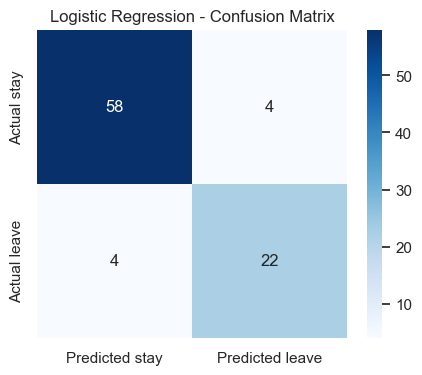

In [34]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## Fairness Audit

Sensitive attributes are not used by the model, but they are still audited after prediction.

Important caution: some groups have very small sample sizes, so these numbers support a governance discussion rather than a hard fairness claim.

In [35]:
audit_test = audit_test.copy()
audit_test["score"] = final_scores
audit_test["prediction"] = final_predictions

sex_audit = fairness_audit(audit_test, "Sex")
race_audit = fairness_audit(audit_test, "RaceDesc")

sex_audit

,n,actual_turnover,predicted_positive,avg_score,predicted_positive_gap_vs_min
Sex,,,,,
F,45,0.3556,0.3778,0.4011,0.1685
M,43,0.2326,0.2093,0.3221,0.0000


In [36]:
race_audit

,n,actual_turnover,predicted_positive,avg_score,predicted_positive_gap_vs_min
RaceDesc,,,,,
White,49,0.3673,0.3878,0.4006,0.3878
Black or African American,23,0.2174,0.2174,0.3077,0.2174
Asian,10,0.2000,0.2000,0.3838,0.2000
Two or more races,5,0.2000,0.0000,0.2538,0.0000
American Indian or Alaska Native,1,0.0000,0.0000,0.0851,0.0000


## Global Explainability

Because SHAP is not required for the jury and the selected model is linear, we use transparent global explanations:
- Logistic Regression coefficients for direction and strength;
- comparator-model feature importance only as a secondary diagnostic reference.

In [37]:
feature_names = logreg_pipeline.named_steps["preprocessor"].get_feature_names_out()
logreg_coefficients = pd.Series(
    logreg_pipeline.named_steps["model"].coef_[0],
    index=feature_names,
).sort_values()

coef_summary = pd.concat(
    [
        logreg_coefficients.head(12).rename("coefficient").to_frame().assign(direction="reduces risk"),
        logreg_coefficients.tail(12).sort_values(ascending=False).rename("coefficient").to_frame().assign(direction="increases risk"),
    ]
)

coef_summary

,coefficient,direction
num__TenureAtReview,-1.705998,reduces risk
cat__RecruitmentSource_Employee Referral,-1.374541,reduces risk
cat__MaritalDesc_Separated,-0.906193,reduces risk
cat__RecruitmentSource_Website,-0.817704,reduces risk
cat__Department_Admin Offices,-0.716828,reduces risk
cat__RecruitmentSource_LinkedIn,-0.691197,reduces risk
num__SpecialProjectsCount,-0.531275,reduces risk
cat__Department_Sales,-0.488472,reduces risk
cat__Position_BI Developer,-0.405738,reduces risk
cat__Position_Shared Services Manager,-0.348931,reduces risk


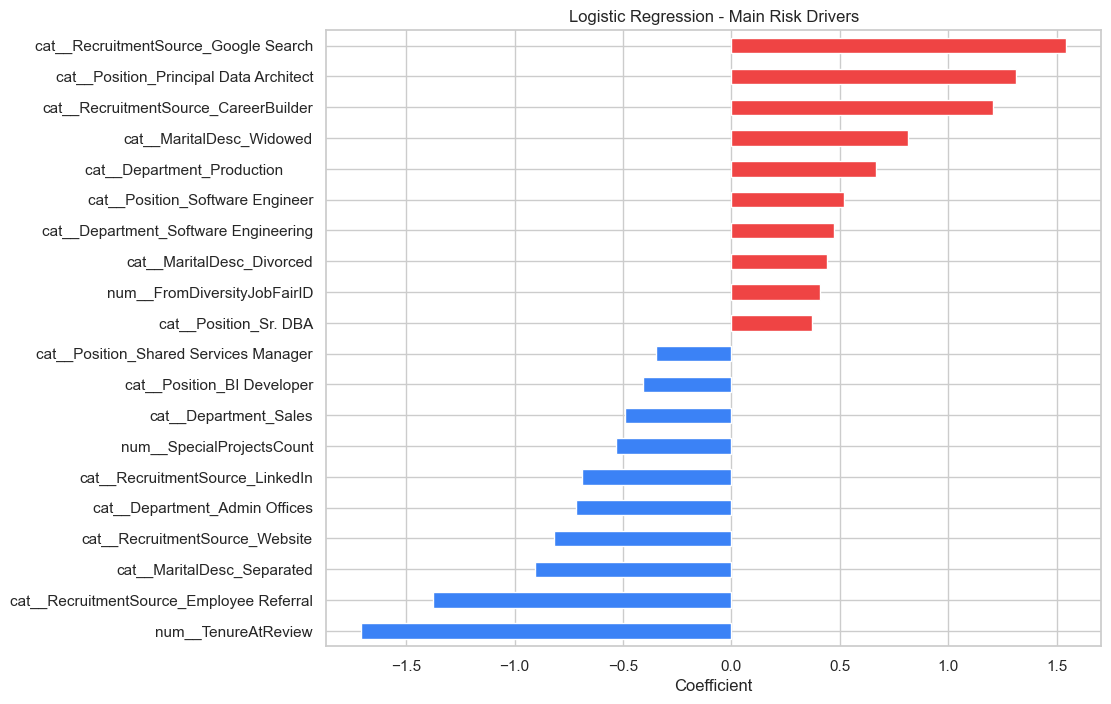

In [38]:
plt.figure(figsize=(10, 8))
plot_coefficients = pd.concat([
    logreg_coefficients.head(10),
    logreg_coefficients.tail(10),
])
plot_coefficients.sort_values().plot(kind="barh", color=["#3b82f6" if v < 0 else "#ef4444" for v in plot_coefficients.sort_values()])
plt.title("Logistic Regression - Main Risk Drivers")
plt.xlabel("Coefficient")
plt.show()

In [39]:
rf_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

rf_importances.head(12).to_frame("importance")

,importance
num__TenureAtReview,0.260970
num__AgeAtReview,0.107221
num__Salary,0.083223
num__EngagementSurvey,0.053720
num__Absences,0.047947
cat__Department_Production,0.041475
cat__RecruitmentSource_LinkedIn,0.036213
num__SpecialProjectsCount,0.034517
cat__RecruitmentSource_Employee Referral,0.032060
cat__RecruitmentSource_Google Search,0.031833


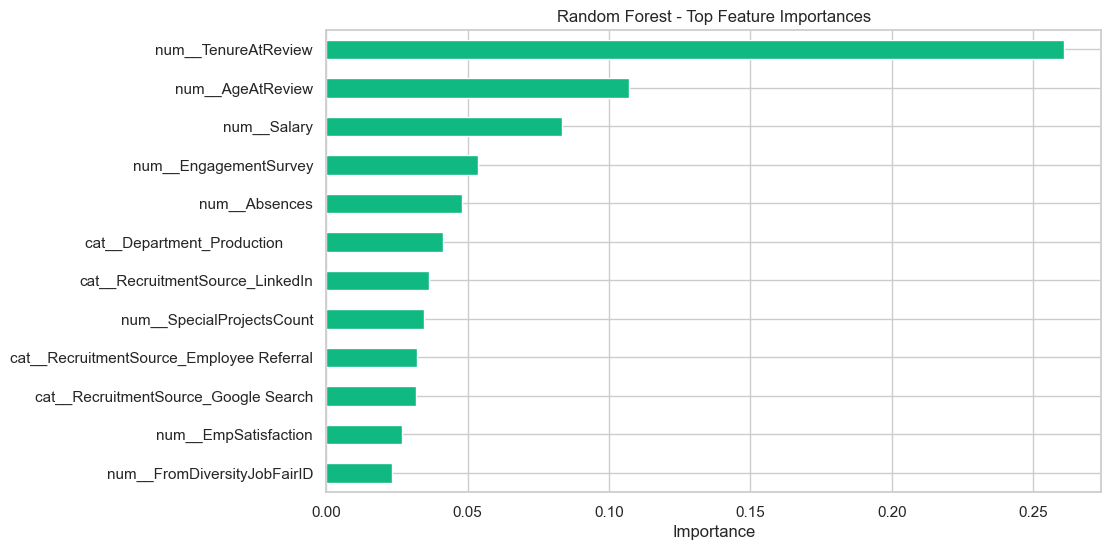

In [40]:
plt.figure(figsize=(10, 6))
rf_importances.head(12).sort_values().plot(kind="barh", color="#10b981")
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance")
plt.show()

## Local Explainability: 2 Anonymized Employee Cases

We show one very high-risk prediction and one very low-risk prediction. This is useful for the oral defense because it turns the model into a concrete HR decision-support story.

In [41]:
case_report = audit_test.copy()
case_report["score"] = final_scores
case_report["prediction"] = final_predictions

high_risk_case_index = case_report[case_report["prediction"] == 1].sort_values("score", ascending=False).index[0]
low_risk_case_index = case_report[case_report["prediction"] == 0].sort_values("score", ascending=True).index[0]

high_risk_case = pd.concat(
    [
        case_report.loc[[high_risk_case_index]],
        X_test.loc[[high_risk_case_index]].reset_index(drop=True),
    ],
    axis=1,
)

low_risk_case = pd.concat(
    [
        case_report.loc[[low_risk_case_index]],
        X_test.loc[[low_risk_case_index]].reset_index(drop=True),
    ],
    axis=1,
)

high_risk_case

,Employee_Alias,Sex,RaceDesc,Termd,TermReason,score,prediction,MaritalDesc,Salary,Position,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,FromDiversityJobFairID,AgeAtReview,TenureAtReview,State
221,EMP_222,M,Asian,1.0,more money,0.993711,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Married,64724.0,Production Technician I,Production,Google Search,Fully Meets,5.0,3.0,0.0,0.0,13.0,0.0,24.0,0.6,MA


In [42]:
low_risk_case

,Employee_Alias,Sex,RaceDesc,Termd,TermReason,score,prediction,MaritalDesc,Salary,Position,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,FromDiversityJobFairID,AgeAtReview,TenureAtReview,State
282,EMP_283,M,White,0.0,N/A-StillEmployed,0.000055,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Separated,64397.0,Area Sales Manager,Sales,Indeed,Exceeds,4.1,3.0,0.0,0.0,6.0,0.0,51.0,13.0,ND


In [43]:
high_explanation = explain_case(logreg_pipeline, X_test.loc[[high_risk_case_index]], top_n=6)
low_explanation = explain_case(logreg_pipeline, X_test.loc[[low_risk_case_index]], top_n=6)

print("High-risk case - strongest risk-up contributions")
display(high_explanation["risk_up"].to_frame("contribution"))
print("High-risk case - strongest risk-down contributions")
display(high_explanation["risk_down"].to_frame("contribution"))

print("Low-risk case - strongest risk-up contributions")
display(low_explanation["risk_up"].to_frame("contribution"))
print("Low-risk case - strongest risk-down contributions")
display(low_explanation["risk_down"].to_frame("contribution"))

High-risk case - strongest risk-up contributions


,contribution
num__TenureAtReview,3.060781
cat__RecruitmentSource_Google Search,1.542724
cat__Department_Production,0.665862
cat__Position_Production Technician I,0.358657
num__EngagementSurvey,0.323509
num__SpecialProjectsCount,0.267881


High-risk case - strongest risk-down contributions


,contribution
num__FromDiversityJobFairID,-0.131119
cat__MaritalDesc_Married,-0.084971
num__Absences,-0.052391
num__DaysLateLast30,-0.032127
cat__Position_Software Engineering Manager,-0.000000
cat__RecruitmentSource_Other,-0.000000


Low-risk case - strongest risk-up contributions


,contribution
num__SpecialProjectsCount,0.267881
num__Absences,0.079044
num__EmpSatisfaction,0.078473
num__Salary,0.014107
cat__RecruitmentSource_Employee Referral,-0.000000
cat__PerformanceScore_Fully Meets,0.000000


Low-risk case - strongest risk-down contributions


,contribution
num__TenureAtReview,-6.561413
cat__MaritalDesc_Separated,-0.906193
cat__Department_Sales,-0.488472
cat__PerformanceScore_Exceeds,-0.334401
cat__RecruitmentSource_Indeed,-0.303682
num__FromDiversityJobFairID,-0.131119


## Demo View: Top 5 Active Employees With Probable Reasons and HR Actions

This section reproduces the logic used in the deployed Streamlit dashboard. It does not stop at a ranked watchlist: it also assigns a probable resignation reason, highlights the main risk drivers, and proposes concrete HR actions for each active employee in the Top 5.

The outputs are decision-support artifacts for HR review, not automated HR decisions.

In [ ]:
deployment_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(X_all)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", solver="liblinear")),
    ]
)
deployment_model.fit(X_all, y_all)

deployment_stats = {
    "overall_turnover_rate": float(modeling_df[TARGET].mean()),
    "department_turnover": modeling_df.groupby("Department")[TARGET].mean().to_dict(),
    "recruitment_turnover": modeling_df.groupby("RecruitmentSource")[TARGET].mean().to_dict(),
    "position_salary_median": modeling_df.groupby("Position")["Salary"].median().to_dict(),
    "high_absence_threshold": float(modeling_df["Absences"].quantile(0.75)),
}

deployment_feature_names = deployment_model.named_steps["preprocessor"].get_feature_names_out()
deployment_coefficients = pd.Series(
    deployment_model.named_steps["model"].coef_[0],
    index=deployment_feature_names,
)

historical_leavers = modeling_df[modeling_df[TARGET] == 1].copy()
historical_leavers["ReasonGroup"] = historical_leavers["TermReason"].map(REASON_GROUP_MAP)
leaver_vectors = deployment_model.named_steps["preprocessor"].transform(historical_leavers[MODEL_FEATURES])
reason_neighbor_model = NearestNeighbors(n_neighbors=min(7, len(historical_leavers)), metric="cosine")
reason_neighbor_model.fit(leaver_vectors)

active_employees = modeling_df[modeling_df[TARGET] == 0].copy()
active_employees["risk_score"] = deployment_model.predict_proba(active_employees[MODEL_FEATURES])[:, 1]

active_vectors = deployment_model.named_steps["preprocessor"].transform(active_employees[MODEL_FEATURES])
if hasattr(active_vectors, "toarray"):
    active_vectors_dense = active_vectors.toarray()
else:
    active_vectors_dense = active_vectors

contribution_frame = pd.DataFrame(
    active_vectors_dense * deployment_coefficients.values,
    index=active_employees.index,
    columns=deployment_feature_names,
)

dashboard_rows = []
for idx, row in active_employees.iterrows():
    transformed_row = deployment_model.named_steps["preprocessor"].transform(row[MODEL_FEATURES].to_frame().T)
    group_probs, raw_probs, raw_votes = compute_reason_distribution(
        row,
        transformed_row,
        historical_leavers,
        reason_neighbor_model,
        deployment_stats,
    )
    probable_reason_group = max(group_probs, key=group_probs.get)
    top_raw_reasons = list(sorted(raw_probs, key=raw_probs.get, reverse=True)[:2])
    contribution_map = contribution_frame.loc[idx].to_dict()
    risk_drivers = [message for message, _ in build_risk_driver_messages(row, contribution_map, deployment_stats)]
    recommended_actions = build_recommended_actions(row, probable_reason_group, top_raw_reasons, deployment_stats)

    dashboard_rows.append(
        {
            "Employee_Alias": row["Employee_Alias"],
            "EmpID": int(row["EmpID"]),
            "Department": row["Department"].strip(),
            "Position": row["Position"],
            "RecruitmentSource": row["RecruitmentSource"],
            "risk_score": float(row["risk_score"]),
            "probable_reason_group": probable_reason_group,
            "reason_confidence": float(group_probs[probable_reason_group]),
            "similar_raw_reasons": ", ".join(top_raw_reasons),
            "reason_distribution": group_probs,
            "raw_reason_votes": raw_votes,
            "risk_drivers": risk_drivers,
            "recommended_actions": recommended_actions,
            "TenureAtReview": row["TenureAtReview"],
            "EngagementSurvey": row["EngagementSurvey"],
            "EmpSatisfaction": row["EmpSatisfaction"],
        }
    )

leaderboard_dashboard = pd.DataFrame(dashboard_rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
top5_dashboard = leaderboard_dashboard.head(TOP_N).copy()

top5_demo_view = top5_dashboard[[
    "Employee_Alias",
    "EmpID",
    "Department",
    "Position",
    "risk_score",
    "probable_reason_group",
    "reason_confidence",
    "similar_raw_reasons",
]].copy()
top5_demo_view.insert(0, "Priority", range(1, len(top5_demo_view) + 1))
top5_demo_view["risk_score"] = top5_demo_view["risk_score"].map(lambda x: f"{x:.0%}")
top5_demo_view["probable_reason_group"] = top5_demo_view["probable_reason_group"].map(reason_display_label)
top5_demo_view["reason_confidence"] = top5_demo_view["reason_confidence"].map(lambda x: f"{x:.0%}")
top5_demo_view = top5_demo_view.rename(
    columns={
        "Employee_Alias": "Employee",
        "Position": "Role",
        "risk_score": "Risk",
        "probable_reason_group": "Likely reason",
        "reason_confidence": "Reason confidence",
        "similar_raw_reasons": "Closest historical reasons",
    }
)

print("Dashboard-aligned Top 5 retention watchlist")
display(top5_demo_view)

demo_employee = top5_dashboard.iloc[0]
demo_summary = pd.DataFrame(
    {
        "Field": [
            "Employee",
            "EmpID",
            "Department",
            "Role",
            "Recruitment source",
            "Risk",
            "Likely reason",
            "Reason confidence",
            "Closest historical reasons",
            "Tenure at review",
            "Engagement survey",
            "Satisfaction",
        ],
        "Value": [
            demo_employee["Employee_Alias"],
            int(demo_employee["EmpID"]),
            demo_employee["Department"],
            demo_employee["Position"],
            demo_employee["RecruitmentSource"],
            f"{demo_employee['risk_score']:.0%}",
            reason_display_label(demo_employee["probable_reason_group"]),
            f"{demo_employee['reason_confidence']:.0%}",
            demo_employee["similar_raw_reasons"],
            f"{demo_employee['TenureAtReview']:.1f} years",
            f"{demo_employee['EngagementSurvey']:.1f}/5",
            f"{int(demo_employee['EmpSatisfaction'])}/5",
        ],
    }
)

demo_risk_drivers = pd.DataFrame({"Main risk drivers": demo_employee["risk_drivers"]})
demo_actions = pd.DataFrame({"Recommended HR actions": demo_employee["recommended_actions"]})
demo_reason_distribution = pd.DataFrame(
    {
        "Reason group": [reason_display_label(reason) for reason in demo_employee["reason_distribution"].keys()],
        "Probability": [round(probability, 4) for probability in demo_employee["reason_distribution"].values()],
    }
).sort_values("Probability", ascending=False)

print("Example employee sheet aligned with the dashboard")
display(demo_summary)
print("Main risk drivers")
display(demo_risk_drivers)
print("Recommended HR actions")
display(demo_actions)
print("Reason distribution")
display(demo_reason_distribution)

## HR Recommendations

Based on the deployed Logistic Regression model, the dashboard-aligned Top 5 watchlist, and the reason/action engine:
1. **Prioritize early-tenure retention actions.** Short tenure is the strongest recurring driver of turnover risk.
2. **Focus on externally sourced hires.** Google Search and CareerBuilder hires appear riskier than employee referrals.
3. **Review Production and similar operational roles.** Some departments and positions consistently contribute more risk.
4. **Use development levers early.** Special projects and stronger performance patterns tend to reduce risk.
5. **Keep a human decision loop.** The model is a prioritization tool, not an automated HR decision engine.

## Limits and Next Steps

**Current limits**
- The dataset is synthetic and relatively small.
- Some fairness groups are under-represented, so disparities must be interpreted cautiously.
- The model is predictive, not causal.
- The probable reason is an informed hypothesis, not ground truth.
- No text feedback has been integrated yet.

**Next steps for the hackathon**
- validate the Top 5 output and the action wording with HR stakeholders;
- polish the oral demo around one employee sheet and the Responsible AI tab;
- optionally add a lightweight NLP block on synthetic HR feedback;
- test threshold and follow-up policies with a human review loop.